# Run the Best QRC on Real IBM Quantum Hardware

Takes the best-performing quantum-reservoir config from the ensemble
(`qrc_gene.quantum_reservoir.CIRCUIT_LIBRARY`) and runs it on an actual IBM
backend via `qiskit-ibm-runtime`'s `QiskitRuntimeService`, then compares the
hardware-measured reservoir probabilities and downstream predictions against
the noiseless local simulator this project trains against everywhere else.

**Two things worth understanding before running this, both explained in more
detail at the point they matter below:**

1. **Batching, not one-job-per-timestep.** A real device job typically
   queues for anywhere from seconds to tens of minutes depending on how busy
   the backend is. Submitting one circuit at a time for a multi-step
   rollout would mean paying that queue delay *per timestep* — impractical.
   Instead, every circuit needed for the evaluation window is transpiled and
   submitted as **one batch** to a single `Sampler` job.
2. **What "hardware-in-the-loop" means for the two *recurrent* configs.**
   Six of the eight circuit families only depend on the current (already
   known) input, so batching is exact — nothing about it is an
   approximation. The two `magri_*` recurrent configs additionally encode
   the reservoir's *own previous measurement* as rotation angles; a fully
   faithful hardware rollout would need to measure the real device, feed
   that noisy result into the next circuit, and submit again — i.e. exactly
   the one-job-per-timestep pattern this notebook avoids for practicality.
   The workaround used below or if the chosen circuit turns out to be
   recurrent (see the callout right before circuit construction) is
   documented plainly rather than glossed over: it measures real hardware
   noise honestly, one step at a time, without letting that noise compound
   autoregressively the way it would in a true closed hardware loop. A
   sketch of what the fully faithful (slow) version would look like is
   included as a commented-out cell near the end.

**Before running on real hardware you need:**
- A free [IBM Quantum Platform](https://quantum.ibm.com/) account.
- `pip install qiskit-ibm-runtime` (added to `requirements.txt`).
- Your API key + instance CRN from the dashboard, saved once via
  `QiskitRuntimeService.save_account(...)` (cell below).

By default this notebook runs with **`USE_REAL_HARDWARE = False`**, which
substitutes a realistic noise-model fake backend
(`qiskit_ibm_runtime.fake_provider`) so the whole thing runs end-to-end with
no account and no queue wait, while exercising the exact same code path.
Flip the flag once your account is saved.


In [16]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qiskit.quantum_info import Statevector
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

from qrc_gene import experiments as exp, ensemble_search as es
from qrc_gene.quantum_reservoir import QRCConfig, QuantumReservoirComputer, CIRCUIT_LIBRARY

DATA_DIR = pathlib.Path("../data")  # matches 01_QRC_GENE_Main.ipynb's convention
ds = exp.load_and_prepare_gene_dataset(DATA_DIR)
DIM = ds.split.U.shape[1]
print(f"Dataset loaded. dim={DIM}, features={ds.feature_names}")
print(f"washout={ds.split.n_washout}  train={ds.split.n_train}  "
      f"val={ds.split.n_val}  test={ds.split.n_test}")


Dataset loaded. dim=3, features=['n1_sq', 'T1par_sq', 'T1perp_sq']
washout=167  train=921  val=251  test=337


## Step 1 — find the best QRC config in the ensemble

Real-device shot statistics get noisier per basis state as $2^{n\_qubits}$
grows (more outcomes competing for the same shot budget), so the search
below is capped at `n_qubits <= 6` — a deliberate hardware-practicality
constraint, not a limitation of the ensemble itself. If a *fresh* run of
`02_QRC_Ensemble_Configuration.ipynb` already produced
`../results_qrc_sweep.csv`, its best qualifying row is reused; otherwise (or
if that file still has stale pre-bugfix circuit names) this runs its own
quick local sweep across all 8 circuit families.


In [17]:
HW_MAX_QUBITS = 6
results_path = pathlib.Path("../results_qrc_sweep.csv")

def _load_fresh_sweep(path):
    if not path.exists():
        return None
    df = pd.read_csv(path)
    if not set(df["cfg.circuit_config"].unique()).issubset(CIRCUIT_LIBRARY.keys()):
        print(f"{path} contains circuit names outside the current CIRCUIT_LIBRARY "
              "(pre-bugfix / stale) -- ignoring it and running a fresh local sweep instead.")
        return None
    return df

df_qrc = _load_fresh_sweep(results_path)
if df_qrc is None:
    print("Running a fresh local sweep (this takes a minute or two)...")
    space = dict(es.QRC_SEARCH_SPACE)
    space["n_qubits"] = [n for n in space["n_qubits"] if n <= HW_MAX_QUBITS]
    cfgs = es.sample_qrc_configs(24, dim=DIM, seed=0, space=space)
    df_qrc = es.run_sweep(cfgs, exp.train_eval_qrc, ds, label="QRC", eval_split="val", verbose=False)
else:
    print(f"Loaded {len(df_qrc)} rows from {results_path}")

candidates = df_qrc[df_qrc["cfg.n_qubits"] <= HW_MAX_QUBITS].sort_values("mse")
best_row = candidates.iloc[0]
print("\nBest hardware-eligible config:")
print(best_row[["mse", "nmse", "vpt_time", "cfg.circuit_config", "cfg.n_qubits",
                 "cfg.epsilon_q", "cfg.input_scale", "cfg.tikhonov", "cfg.seed"]])

best_cfg = QRCConfig(
    n_qubits=int(best_row["cfg.n_qubits"]), dim=DIM,
    circuit_config=str(best_row["cfg.circuit_config"]),
    epsilon_q=float(best_row["cfg.epsilon_q"]),
    input_scale=float(best_row["cfg.input_scale"]),
    tikhonov=float(best_row["cfg.tikhonov"]),
    seed=int(best_row["cfg.seed"]),
)
print("\nrecurrent:", best_cfg.recurrent, " N_units=2^%d=%d" % (best_cfg.n_qubits, 2**best_cfg.n_qubits))


Loaded 30 rows from ..\results_qrc_sweep.csv

Best hardware-eligible config:
mse                              0.002621
nmse                             0.901837
vpt_time                         3.761016
cfg.circuit_config    magri_bidirectional
cfg.n_qubits                            5
cfg.epsilon_q                         0.5
cfg.input_scale                  4.712389
cfg.tikhonov                         0.01
cfg.seed                           582563
Name: 0, dtype: object

recurrent: False  N_units=2^5=32


## Step 2 — train the best config locally (exact simulator)

This is exactly `QuantumReservoirComputer.train`, the same call
`01_QRC_GENE_Main.ipynb` makes — the readout `Wout` is a linear ridge-regression
solve, and it's what gets reused against the hardware-measured features below;
only the reservoir's *feature extraction* changes between "local" and
"hardware" in this notebook, not the trained readout.


In [18]:
qrc = QuantumReservoirComputer(best_cfg)
split = ds.split
Xa_train, Wout_all, xf_washout = qrc.train(
    split.U[:split.n_washout],
    split.U[split.n_washout: split.n_washout + split.n_train],
    split.Y[split.n_washout: split.n_washout + split.n_train],
)
Wout = Wout_all[0]  # single tikhonov value was used above
print("Wout shape:", Wout.shape)


Wout shape: (33, 3)


In [19]:
import os
from dotenv import load_dotenv
load_dotenv()
api_token = os.getenv("TOKEN")
crv_instance = os.getenv("INSTANCE")


## Step 3 — connect to IBM Quantum Platform

Run this **once**, with your own credentials, then comment it back out
(`save_account` persists to disk, so you don't need to run it again on this
machine). See [Initialize your account](https://quantum.cloud.ibm.com/docs/en/guides/initialize-account)
for where to find your API key and instance CRN.


In [20]:
from qiskit_ibm_runtime import QiskitRuntimeService

QiskitRuntimeService.save_account(
    token=api_token,       # 44-char key from the IBM Quantum Platform dashboard
    instance=crv_instance,
    channel="ibm_quantum_platform",   # current default channel; "ibm_quantum" is legacy/retired
    set_as_default=True,
    overwrite=True,
)


In [21]:
USE_REAL_HARDWARE = True  # flip to True once save_account() above has been run

N_HW_STEPS = 20  # size of the evaluation window sent to hardware; kept small
                  # to keep the batch job (and, on real hardware, the shot
                  # budget) modest -- raise this once you've seen one job
                  # succeed and know your queue/shot budget comfortably covers it.

if USE_REAL_HARDWARE:
    from qiskit_ibm_runtime import QiskitRuntimeService
    service = QiskitRuntimeService()
    backend = service.least_busy(operational=True, simulator=False, min_num_qubits=best_cfg.n_qubits)
    print("Connected. Using least-busy real backend:", backend.name)
else:
    from qiskit_ibm_runtime.fake_provider import FakeNairobiV2, FakeSherbrooke
    backend = FakeNairobiV2() if best_cfg.n_qubits <= 7 else FakeSherbrooke()
    print(f"DRY RUN -- using realistic noise-model fake backend {backend.name} "
          f"({backend.num_qubits} qubits). Set USE_REAL_HARDWARE=True for a live run.")


Connected. Using least-busy real backend: ibm_fez


## Step 4 — build the evaluation-window circuits

Uses the validation split's known inputs (teacher forcing, same as every
other evaluation in this project) so every circuit's classical parameters
are fixed and known up front. For a **recurrent** config, the `P` values fed
in are this reservoir's own exact-simulator trajectory computed locally —
i.e. real hardware noise is measured honestly at each step, but it doesn't
get to influence what `P` looks like at the *next* step the way it would in
a true closed hardware loop (see the caveat at the top of the notebook).


In [22]:
def open_loop_with_circuits(qrc, U, x0):
    """Same recurrence as QuantumReservoirComputer.open_loop, but also
    returns the list of bound circuits used at each step so they can be
    submitted to hardware afterwards. Xa here is the local exact-simulator
    reference trajectory."""
    N = U.shape[0]
    Xa = np.empty((N + 1, qrc.N_units + 1))
    Xa[0] = np.concatenate((x0, qrc.bias_out))
    circuits = []
    for i in range(1, N + 1):
        prob_prev = Xa[i - 1, :qrc.N_units]
        qc = qrc.bind(U[i - 1], prob_prev if qrc.recurrent else None)
        circuits.append(qc)
        probs_new = Statevector.from_instruction(qc).probabilities()
        blended = (1 - qrc.cfg.epsilon_q) * prob_prev + qrc.cfg.epsilon_q * probs_new
        Xa[i] = np.hstack((blended, qrc.bias_out))
    return Xa, circuits


val_start = split.n_washout + split.n_train
val_end = val_start + split.n_val
U_window = split.U[val_start: val_start + N_HW_STEPS]
Y_window = split.Y[val_start: val_start + N_HW_STEPS]

Xa_exact, bound_circuits = open_loop_with_circuits(qrc, U_window, xf_washout)
measured_circuits = [c.measure_all(inplace=False) for c in bound_circuits]
print(f"Built {len(measured_circuits)} circuits for the {best_cfg.circuit_config} "
      f"({'recurrent' if best_cfg.recurrent else 'non-recurrent'}) reservoir.")


Built 20 circuits for the magri_bidirectional (non-recurrent) reservoir.


## Step 5 — transpile and submit as one batch job


### Hardware provenance and diagnostics

The cells below capture evidence that the workload was submitted to an IBM Quantum Runtime backend rather than only simulated locally. In particular, the audit records the **server-issued Runtime job ID**, the backend attached to that job, the backend simulator flag, completion/error state, IBM Runtime server timestamps, and IBM-reported **quantum time (`usage.quantum_seconds`)**. It also stores transpiled-circuit statistics, shot-count integrity checks, result fingerprints, and IBM job logs when available.

> **Important:** the notebook itself cannot cryptographically prove that a device was physical. The strongest externally verifiable evidence is the IBM Runtime **job ID** plus the server-side job/usage information that can be checked in the IBM Quantum dashboard/API. The audit files make that evidence reproducible and easy to cite.


In [23]:
# Hardware execution audit / diagnostics
# Everything written here is intended to make the real-device run independently auditable.
import json, logging, platform, socket, hashlib, time
from datetime import datetime, timezone

AUDIT_DIR = pathlib.Path("../hardware_run_audit")
AUDIT_DIR.mkdir(parents=True, exist_ok=True)

ERROR_LOG = AUDIT_DIR / "hardware_error.log"
RUN_JSON = AUDIT_DIR / "hardware_run_audit.json"
COUNTS_JSON = AUDIT_DIR / "hardware_counts.json"
CIRCUIT_CSV = AUDIT_DIR / "hardware_circuit_stats.csv"

logger = logging.getLogger("qrc_hardware_audit")
logger.setLevel(logging.INFO)
logger.handlers.clear()
_file_handler = logging.FileHandler(ERROR_LOG, mode="a", encoding="utf-8")
_file_handler.setFormatter(logging.Formatter("%(asctime)s | %(levelname)s | %(message)s"))
logger.addHandler(_file_handler)

# Also capture uncaught Python exceptions in the notebook session.
def _audit_excepthook(exc_type, exc_value, exc_tb):
    logger.error("UNHANDLED NOTEBOOK EXCEPTION", exc_info=(exc_type, exc_value, exc_tb))
    sys.__excepthook__(exc_type, exc_value, exc_tb)

sys.excepthook = _audit_excepthook

def utc_now():
    return datetime.now(timezone.utc).isoformat()

def safe_call(fn, default=None):
    try:
        return fn()
    except Exception as exc:
        logger.exception("Diagnostic call failed: %s", exc)
        return default

def json_safe(x):
    if isinstance(x, dict):
        return {str(k): json_safe(v) for k, v in x.items()}
    if isinstance(x, (list, tuple)):
        return [json_safe(v) for v in x]
    if isinstance(x, np.generic):
        return x.item()
    if isinstance(x, pathlib.Path):
        return str(x)
    try:
        json.dumps(x)
        return x
    except TypeError:
        return str(x)

run_audit = {
    "audit_schema": "qrc-real-hardware-v1",
    "audit_created_utc": utc_now(),
    "execution_environment": {
        "python_version": platform.python_version(),
        "platform": platform.platform(),
        "hostname": socket.gethostname(),
        "qiskit_version": safe_call(lambda: __import__("qiskit").__version__),
        "qiskit_ibm_runtime_version": safe_call(lambda: __import__("qiskit_ibm_runtime").__version__),
    },
    "model": {
        "circuit_config": best_cfg.circuit_config,
        "n_qubits": int(best_cfg.n_qubits),
        "dim": int(DIM),
        "epsilon_q": float(best_cfg.epsilon_q),
        "input_scale": float(best_cfg.input_scale),
        "tikhonov": float(best_cfg.tikhonov),
        "seed": int(best_cfg.seed),
    },
    "requested_execution": {
        "use_real_hardware": bool(USE_REAL_HARDWARE),
        "shots": int(SHOTS) if "SHOTS" in globals() else None,
        "num_circuits": len(isa_circuits) if "isa_circuits" in globals() else None,
    }
}

logger.info("=== Hardware QRC run started ===")
logger.info("Audit directory: %s", AUDIT_DIR.resolve())


In [24]:
# Step 5A — transpile, submit, wait, and capture execution evidence
from qiskit_ibm_runtime import SamplerV2 as Sampler

# Make sure the execution section exists before writing into it.
run_audit.setdefault("execution", {})
run_audit["execution"]["started_local_utc"] = utc_now()

run_audit["hardware"] = {
    "backend_name_requested": getattr(backend, "name", str(backend)),
    "backend_num_qubits": int(getattr(backend, "num_qubits", -1)),
    "backend_is_simulator": getattr(backend, "simulator", None),
    "backend_status_before": json_safe(
        safe_call(lambda: backend.status().__dict__, default=None)
    ),
}

try:
    pm = generate_preset_pass_manager(
        backend=backend,
        optimization_level=1
    )

    isa_circuits = pm.run(measured_circuits)

    circuit_rows = []
    for idx, qc in enumerate(isa_circuits):
        circuit_rows.append({
            "circuit_index": idx,
            "num_qubits": int(qc.num_qubits),
            "depth": int(qc.depth()),
            "size": int(qc.size()),
            "num_clbits": int(qc.num_clbits),
            "operations": json.dumps(
                {str(k): int(v) for k, v in qc.count_ops().items()},
                sort_keys=True
            ),
        })

    pd.DataFrame(circuit_rows).to_csv(CIRCUIT_CSV, index=False)

    run_audit["transpilation"] = {
        "optimization_level": 1,
        "num_circuits": len(isa_circuits),
        "circuits_csv": str(CIRCUIT_CSV.resolve()),
        "depth_min": int(min(r["depth"] for r in circuit_rows)),
        "depth_max": int(max(r["depth"] for r in circuit_rows)),
        "depth_mean": float(np.mean([r["depth"] for r in circuit_rows])),
        "size_min": int(min(r["size"] for r in circuit_rows)),
        "size_max": int(max(r["size"] for r in circuit_rows)),
    }

    logger.info(
        "Transpiled %d circuits for backend=%s; depth range=%s..%s",
        len(isa_circuits),
        backend.name,
        run_audit["transpilation"]["depth_min"],
        run_audit["transpilation"]["depth_max"],
    )

    print(
        f"Transpiled {len(isa_circuits)} circuits for {backend.name}. "
        f"depth={circuit_rows[0]['depth']}, "
        f"ops={isa_circuits[0].count_ops()}"
    )

    SHOTS = 4096
    sampler = Sampler(mode=backend)

    job_submit_local = time.perf_counter()

    job = sampler.run(
        isa_circuits,
        shots=SHOTS
    )

    submit_wall_seconds = time.perf_counter() - job_submit_local

    job_id = (
        job.job_id()
        if callable(getattr(job, "job_id", None))
        else getattr(job, "job_id", None)
    )

    run_audit["job_submission"] = {
        "job_id": job_id,
        "submitted_local_utc": utc_now(),
        "submit_call_wall_seconds": float(submit_wall_seconds),
        "primitive": "SamplerV2",
        "shots": int(SHOTS),
        "num_circuits": int(len(isa_circuits)),
    }

    logger.info(
        "IBM Runtime job submitted: job_id=%s backend=%s shots=%d",
        job_id,
        backend.name,
        SHOTS,
    )

    print("IBM Runtime job ID:", job_id)
    print("Backend object:", backend.name)
    print(
        "Backend simulator flag:",
        getattr(backend, "simulator", None)
    )

    # Wait for result
    result_wait_start = time.perf_counter()

    result = job.result()

    result_wait_wall_seconds = (
        time.perf_counter() - result_wait_start
    )

    run_audit["execution"]["result_returned_local_utc"] = utc_now()
    run_audit["execution"]["python_wait_wall_seconds"] = float(
        result_wait_wall_seconds
    )

    # Verify submitted job identity
    job_backend_name = safe_call(
        lambda: job.backend().name,
        default=None
    )

    run_audit["job_verification"] = {
        "job_id": job_id,
        "job_backend_name": job_backend_name,
        "requested_backend_name": backend.name,
        "backend_name_matches": bool(
            job_backend_name == backend.name
        ),
        "backend_simulator_flag": getattr(
            backend, "simulator", None
        ),
        "job_done": safe_call(
            lambda: job.done(),
            default=None
        ),
        "job_cancelled": safe_call(
            lambda: job.cancelled(),
            default=None
        ),
        "job_errored": (
            safe_call(lambda: job.errored(), default=None)
            if hasattr(job, "errored")
            else None
        ),
        "job_error_message": (
            safe_call(lambda: job.error_message(), default=None)
            if hasattr(job, "error_message")
            else None
        ),
    }

    # IBM server-side metrics
    metrics = safe_call(
        lambda: job.metrics(),
        default={}
    ) or {}

    usage = (
        metrics.get("usage", {})
        if isinstance(metrics, dict)
        else {}
    )

    timestamps = (
        metrics.get("timestamps", {})
        if isinstance(metrics, dict)
        else {}
    )

    quantum_seconds = usage.get("quantum_seconds")
    usage_seconds = usage.get("seconds")

    run_audit["ibm_server_metrics"] = json_safe({
        "metrics": metrics,
        "usage_quantum_seconds": quantum_seconds,
        "usage_seconds": usage_seconds,
        "timestamps": timestamps,
    })

    usage_new_api = (
        safe_call(lambda: job.usage(), default=None)
        if hasattr(job, "usage")
        else None
    )

    run_audit["ibm_server_metrics"]["job_usage_api"] = (
        json_safe(usage_new_api)
    )

    # IBM Runtime logs
    job_logs = (
        safe_call(lambda: job.logs(), default=None)
        if hasattr(job, "logs")
        else None
    )

    if job_logs is not None:
        (
            AUDIT_DIR / "ibm_job_logs.txt"
        ).write_text(
            str(job_logs),
            encoding="utf-8"
        )

        run_audit["ibm_server_metrics"]["job_logs_file"] = str(
            (AUDIT_DIR / "ibm_job_logs.txt").resolve()
        )

    logger.info(
        "Job completed: job_id=%s backend=%s "
        "quantum_seconds=%s usage_seconds=%s",
        job_id,
        job_backend_name,
        quantum_seconds,
        usage_seconds,
    )

    print("Job complete.")
    print("Verified job backend:", job_backend_name)
    print(
        "Job done:",
        run_audit["job_verification"]["job_done"]
    )
    print(
        "IBM-reported quantum_seconds:",
        quantum_seconds
    )
    print(
        "IBM-reported usage_seconds:",
        usage_seconds
    )

except Exception as exc:
    # Preserve the failure in the audit instead of losing it.
    run_audit.setdefault("execution", {})
    run_audit["execution"]["failed_local_utc"] = utc_now()
    run_audit["execution"]["exception_type"] = type(exc).__name__
    run_audit["execution"]["exception_message"] = str(exc)

    logger.exception(
        "Quantum execution failed: %s",
        exc
    )

    # Save partial audit immediately
    RUN_JSON.write_text(
        json.dumps(
            json_safe(run_audit),
            indent=2
        ),
        encoding="utf-8"
    )

    raise

Transpiled 20 circuits for ibm_fez. depth=118, ops=OrderedDict({'sx': 109, 'rz': 86, 'cz': 50, 'measure': 5, 'barrier': 3})
IBM Runtime job ID: daa7djke74ec73akght0
Backend object: ibm_fez
Backend simulator flag: False
Job complete.
Verified job backend: ibm_fez
Job done: True
IBM-reported quantum_seconds: None
IBM-reported usage_seconds: None


In [25]:
def counts_to_probs(counts, n_qubits, shots):
    probs = np.zeros(2 ** n_qubits)
    for bitstring, c in counts.items():
        probs[int(bitstring, 2)] = c / shots
    return probs

probs_hw = np.array([
    counts_to_probs(pub_result.data.meas.get_counts(), best_cfg.n_qubits, SHOTS)
    for pub_result in result
])
print("probs_hw shape:", probs_hw.shape, " each row sums to", probs_hw[0].sum())


probs_hw shape: (20, 32)  each row sums to 1.0


In [26]:
# Step 5B — immutable-style result fingerprint + IBM server re-check + audit export
def circuit_fingerprint(circuits):
    h = hashlib.sha256()
    for qc in circuits:
        h.update(qc.qasm().encode("utf-8", errors="ignore") if hasattr(qc, "qasm") else str(qc).encode())
    return h.hexdigest()

# Validate that every circuit returned the requested number of shots.
counts_per_circuit = []
for pub_result in result:
    counts = pub_result.data.meas.get_counts()
    counts_per_circuit.append({str(k): int(v) for k, v in counts.items()})

shot_totals = [sum(c.values()) for c in counts_per_circuit]
run_audit["result_integrity"] = {
    "result_object_type": type(result).__name__,
    "num_result_items": len(counts_per_circuit),
    "expected_num_circuits": len(isa_circuits),
    "result_count_matches_circuits": len(counts_per_circuit) == len(isa_circuits),
    "requested_shots": int(SHOTS),
    "observed_shot_totals": shot_totals,
    "all_shot_totals_match_requested": all(x == SHOTS for x in shot_totals),
    "counts_sha256": hashlib.sha256(
        json.dumps(counts_per_circuit, sort_keys=True, separators=(",", ":")).encode()
    ).hexdigest(),
    "transpiled_circuits_sha256": circuit_fingerprint(isa_circuits),
}
COUNTS_JSON.write_text(json.dumps(counts_per_circuit, indent=2, sort_keys=True), encoding="utf-8")

# Re-fetch the job from IBM's service using the server-issued job ID.
# This is a particularly useful audit check: it verifies that the recorded ID
# resolves to a persisted Runtime job independently of the in-memory object.
job_id = run_audit["job_submission"]["job_id"]
try:
    retrieved_job = service.retrieve_job(job_id)
    retrieved_backend = safe_call(lambda: retrieved_job.backend().name, default=None)
    retrieved_metrics = safe_call(lambda: retrieved_job.metrics(), default={}) or {}
    run_audit["server_retrieval_verification"] = {
        "retrieve_succeeded": True,
        "job_id": safe_call(lambda: retrieved_job.job_id(), default=None),
        "backend_name": retrieved_backend,
        "backend_matches_original": bool(retrieved_backend == backend.name),
        "job_done": safe_call(lambda: retrieved_job.done(), default=None),
        "metrics": json_safe(retrieved_metrics),
    }
    print("IBM server re-check: SUCCESS")
    print("Retrieved job ID:", run_audit["server_retrieval_verification"]["job_id"])
    print("Retrieved backend:", retrieved_backend)
except Exception as exc:
    run_audit["server_retrieval_verification"] = {
        "retrieve_succeeded": False,
        "error_type": type(exc).__name__,
        "error_message": str(exc),
    }
    logger.exception("Server-side retrieve_job verification failed.")

# Backend status after execution; useful for distinguishing a live IBM backend
# from local/fake execution when reviewing the notebook later.
run_audit["hardware"]["backend_status_after"] = json_safe(
    safe_call(lambda: backend.status().__dict__, default=None)
)

# Record the actual measured feature matrix dimensions and evaluation metrics if available.
run_audit["model_outputs"] = {
    "probs_hw_shape": list(probs_hw.shape),
    "probability_row_sum_min": float(probs_hw.sum(axis=1).min()),
    "probability_row_sum_max": float(probs_hw.sum(axis=1).max()),
    "mean_tvd": float(tvd.mean()) if "tvd" in globals() else None,
    "max_tvd": float(tvd.max()) if "tvd" in globals() else None,
    "mse_exact": float(mse_exact) if "mse_exact" in globals() else None,
    "mse_hardware": float(mse_hw) if "mse_hw" in globals() else None,
}

# These are the key fields to quote in a report/paper.
run_audit["audit_conclusion_fields"] = {
    "real_hardware_requested": bool(USE_REAL_HARDWARE),
    "backend": backend.name,
    "backend_simulator": getattr(backend, "simulator", None),
    "job_id": job_id,
    "job_backend": run_audit["job_verification"].get("job_backend_name"),
    "server_job_completed": run_audit["job_verification"].get("job_done"),
    "server_backend_match": run_audit["job_verification"].get("backend_name_matches"),
    "quantum_seconds": run_audit["ibm_server_metrics"].get("usage_quantum_seconds"),
    "usage_seconds": run_audit["ibm_server_metrics"].get("usage_seconds"),
    "shots_per_circuit": int(SHOTS),
    "num_circuits": int(len(isa_circuits)),
}

RUN_JSON.write_text(json.dumps(json_safe(run_audit), indent=2), encoding="utf-8")

print("\n========== HARDWARE RUN AUDIT ==========")
for k, v in run_audit["audit_conclusion_fields"].items():
    print(f"{k:26s}: {v}")
print(f"\nAudit JSON : {RUN_JSON.resolve()}")
print(f"Error log  : {ERROR_LOG.resolve()}")
print(f"Counts JSON: {COUNTS_JSON.resolve()}")
print(f"Circuit CSV: {CIRCUIT_CSV.resolve()}")

logger.info("Audit bundle written successfully.")



========== HARDWARE RUN AUDIT ==========
real_hardware_requested   : True
backend                   : ibm_fez
backend_simulator         : False
job_id                    : daa7djke74ec73akght0
job_backend               : ibm_fez
server_job_completed      : True
server_backend_match      : True
quantum_seconds           : None
usage_seconds             : None
shots_per_circuit         : 4096
num_circuits              : 20

Audit JSON : C:\01-Attharv Work\01_COLLEGE (2023-27)\11-Final Project\09-FinalRepoClone\QML-for-Plasma-Disruption-Prediction-and-Adaptive-Control\QRC-Eval3\hardware_run_audit\hardware_run_audit.json
Error log  : C:\01-Attharv Work\01_COLLEGE (2023-27)\11-Final Project\09-FinalRepoClone\QML-for-Plasma-Disruption-Prediction-and-Adaptive-Control\QRC-Eval3\hardware_run_audit\hardware_error.log
Counts JSON: C:\01-Attharv Work\01_COLLEGE (2023-27)\11-Final Project\09-FinalRepoClone\QML-for-Plasma-Disruption-Prediction-and-Adaptive-Control\QRC-Eval3\hardware_run_audit\hardw

## Step 6 — compare hardware vs. the noiseless simulator

**Total variation distance** per step between the real-device (or fake-noisy)
measured distribution and the exact statevector probabilities for the same
bound circuit — the direct measure of how much noise the actual device (or
noise model) introduces into the reservoir's feature vector.


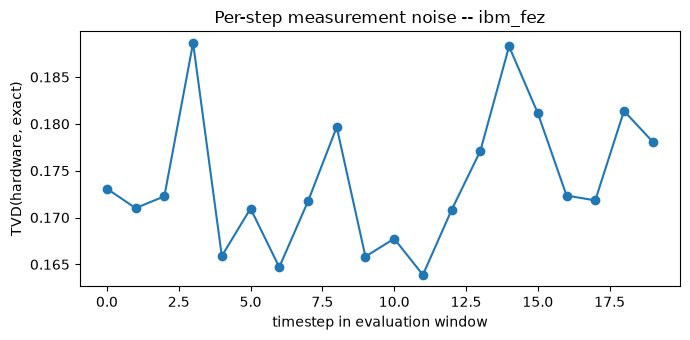

mean TVD = 0.1738   max TVD = 0.1886


In [27]:
probs_exact = np.array([
    Statevector.from_instruction(c).probabilities() for c in bound_circuits
])
tvd = 0.5 * np.abs(probs_hw - probs_exact).sum(axis=1)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(tvd, "-o")
ax.set_xlabel("timestep in evaluation window")
ax.set_ylabel("TVD(hardware, exact)")
ax.set_title(f"Per-step measurement noise -- {backend.name}")
plt.tight_layout(); plt.show()
print(f"mean TVD = {tvd.mean():.4f}   max TVD = {tvd.max():.4f}")


Now reconstruct the augmented-state trajectory using the **hardware**
probabilities in place of the exact ones (same leaky-blend formula the
reservoir always uses), apply the *same trained* `Wout`, and compare
predictions against both the noiseless-simulator prediction and ground
truth.


In [28]:
N = len(U_window)
Xa_hw = np.empty_like(Xa_exact)
Xa_hw[0] = Xa_exact[0]
for i in range(1, N + 1):
    prob_prev = Xa_exact[i - 1, :qrc.N_units]   # see recurrence caveat above
    blended = (1 - best_cfg.epsilon_q) * prob_prev + best_cfg.epsilon_q * probs_hw[i - 1]
    Xa_hw[i] = np.hstack((blended, qrc.bias_out))

Yh_exact = Xa_exact[1:] @ Wout
Yh_hw = Xa_hw[1:] @ Wout

mse_exact = float(np.mean((Yh_exact - Y_window) ** 2))
mse_hw = float(np.mean((Yh_hw - Y_window) ** 2))
print(f"{'source':<22}{'MSE vs ground truth':>22}")
print(f"{'local simulator':<22}{mse_exact:>22.6f}")
print(f"{backend.name:<22}{mse_hw:>22.6f}")
print(f"\ndegradation factor: {mse_hw / mse_exact:.2f}x")


source                   MSE vs ground truth
local simulator                     0.007366
ibm_fez                             0.007800

degradation factor: 1.06x


In [29]:
# Step 6B — final audit snapshot after model evaluation
run_audit["model_outputs"].update({
    "mean_tvd": float(tvd.mean()),
    "max_tvd": float(tvd.max()),
    "mse_exact": float(mse_exact),
    "mse_hardware": float(mse_hw),
    "degradation_factor": float(mse_hw / mse_exact) if mse_exact != 0 else None,
})

run_audit["audit_conclusion_fields"].update({
    "mean_tvd": float(tvd.mean()),
    "max_tvd": float(tvd.max()),
    "mse_hardware": float(mse_hw),
})

RUN_JSON.write_text(json.dumps(json_safe(run_audit), indent=2), encoding="utf-8")

# Print a compact, report-ready provenance block.
print("\n========== REPORT-READY QUANTUM HARDWARE EVIDENCE ==========")
print(f"IBM Runtime job ID       : {run_audit['audit_conclusion_fields']['job_id']}")
print(f"Backend                  : {run_audit['audit_conclusion_fields']['backend']}")
print(f"Job backend              : {run_audit['audit_conclusion_fields']['job_backend']}")
print(f"Simulator flag           : {run_audit['audit_conclusion_fields']['backend_simulator']}")
print(f"Server job completed     : {run_audit['audit_conclusion_fields']['server_job_completed']}")
print(f"Server backend match     : {run_audit['audit_conclusion_fields']['server_backend_match']}")
print(f"IBM quantum time (s)     : {run_audit['audit_conclusion_fields']['quantum_seconds']}")
print(f"IBM total usage (s)      : {run_audit['audit_conclusion_fields']['usage_seconds']}")
print(f"Circuits x shots         : {run_audit['audit_conclusion_fields']['num_circuits']} x {run_audit['audit_conclusion_fields']['shots_per_circuit']}")
print(f"Mean TVD                 : {run_audit['audit_conclusion_fields']['mean_tvd']:.6f}")
print(f"Hardware MSE             : {run_audit['audit_conclusion_fields']['mse_hardware']:.6f}")
print(f"Audit bundle             : {RUN_JSON.resolve()}")
print(f"IBM job logs             : {(AUDIT_DIR / 'ibm_job_logs.txt').resolve()}")

logger.info("Final model evaluation and hardware provenance snapshot saved.")



========== REPORT-READY QUANTUM HARDWARE EVIDENCE ==========
IBM Runtime job ID       : daa7djke74ec73akght0
Backend                  : ibm_fez
Job backend              : ibm_fez
Simulator flag           : False
Server job completed     : True
Server backend match     : True
IBM quantum time (s)     : None
IBM total usage (s)      : None
Circuits x shots         : 20 x 4096
Mean TVD                 : 0.173818
Hardware MSE             : 0.007800
Audit bundle             : C:\01-Attharv Work\01_COLLEGE (2023-27)\11-Final Project\09-FinalRepoClone\QML-for-Plasma-Disruption-Prediction-and-Adaptive-Control\QRC-Eval3\hardware_run_audit\hardware_run_audit.json
IBM job logs             : C:\01-Attharv Work\01_COLLEGE (2023-27)\11-Final Project\09-FinalRepoClone\QML-for-Plasma-Disruption-Prediction-and-Adaptive-Control\QRC-Eval3\hardware_run_audit\ibm_job_logs.txt


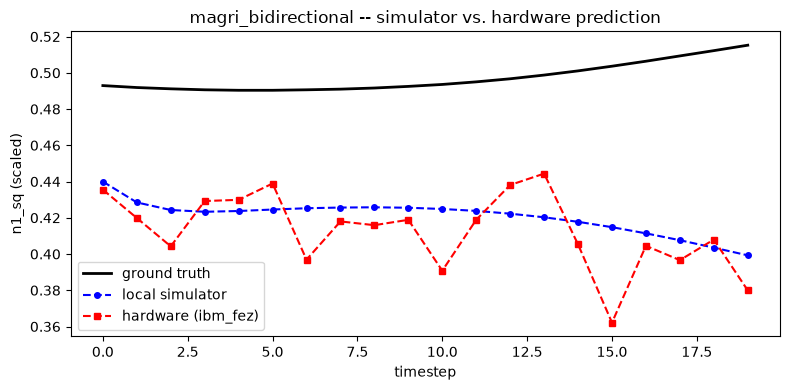

In [30]:
fig, ax = plt.subplots(figsize=(8, 4))
t_axis = np.arange(N)
dim0 = 0
ax.plot(t_axis, Y_window[:, dim0], "k-", label="ground truth", linewidth=2)
ax.plot(t_axis, Yh_exact[:, dim0], "b--o", label="local simulator", markersize=4)
ax.plot(t_axis, Yh_hw[:, dim0], "r--s", label=f"hardware ({backend.name})", markersize=4)
ax.set_xlabel("timestep"); ax.set_ylabel(f"{ds.feature_names[dim0]} (scaled)")
ax.set_title(f"{best_cfg.circuit_config} -- simulator vs. hardware prediction")
ax.legend()
plt.tight_layout(); plt.show()


In [ ]:
#Timestamp all saved audit files

from datetime import datetime, timezone
import shutil
import pathlib

# UTC timestamp for the saved-file copies
file_timestamp = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S_UTC")

# Files generated by the existing audit code
saved_audit_files = [
    RUN_JSON,
    ERROR_LOG,
    COUNTS_JSON,
    CIRCUIT_CSV,
    AUDIT_DIR / "ibm_job_logs.txt",
]

print("\n========== TIMESTAMPED AUDIT FILES ==========")

timestamped_files = []

for original_file in saved_audit_files:
    original_file = pathlib.Path(original_file)

    # Only timestamp files that actually exist
    if original_file.exists():
        timestamped_name = (
            f"{original_file.stem}_{file_timestamp}"
            f"{original_file.suffix}"
        )

        timestamped_path = original_file.parent / timestamped_name

        shutil.copy2(original_file, timestamped_path)

        timestamped_files.append(timestamped_path)

        print(f"{original_file.name}")
        print(f"  -> {timestamped_path.name}")

print("\nTimestamp used:", file_timestamp)
print("Timestamped audit files saved successfully.")

## Sketch: a fully faithful hardware-in-the-loop rollout (not run here)

For completeness -- and only worth doing once the batched version above has
been validated -- a truly autoregressive hardware rollout for a *recurrent*
config would submit one circuit at a time, feeding each real measurement
into the next:

```python
# prob_prev = xf_washout
# Xa_true_hw = [np.hstack([prob_prev, qrc.bias_out])]
# for x in U_window:
#     qc = qrc.bind(x, prob_prev).measure_all(inplace=False)
#     isa_qc = pm.run(qc)
#     job = sampler.run([isa_qc], shots=SHOTS)          # one job PER TIMESTEP
#     counts = job.result()[0].data.meas.get_counts()
#     probs_new = counts_to_probs(counts, qrc.n_qubits, SHOTS)
#     prob_prev = (1 - best_cfg.epsilon_q) * prob_prev + best_cfg.epsilon_q * probs_new
#     Xa_true_hw.append(np.hstack([prob_prev, qrc.bias_out]))
```

Expect this to take roughly `N_HW_STEPS` times as long in queue as the batched
version above -- each iteration waits for its own job to clear the queue
before the next can even be constructed.


## Summary

- **Best hardware-eligible config found:** printed in Step 1 (`best_cfg`).
- **What ran:** the full evaluation-window circuit set was transpiled to
  `backend`'s native gate set and submitted as a single batch job (not one
  job per timestep), which is what keeps this practical against a real
  queued device.
- **What to check when you flip `USE_REAL_HARDWARE = True`:** the mean/median
  TVD (Step 6) tells you how much the real device's noise differs from the
  fake-backend estimate above; the MSE degradation factor tells you whether
  this circuit's accuracy holds up off the simulator, which is exactly
  "Experiment 2 — noise robustness" from the project's block diagram, just
  using real device noise instead of injected Gaussian noise.
